# 权重衰退

In [1]:
import sys
sys.path.insert(0, '..')
%matplotlib inline
import torch
from torch import nn
from d2l_compat import *

In [4]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test)
test_iter = load_array(test_data, batch_size, is_train=False)
'''
synthetic_data：这是一个辅助函数，用于生成符合线性模型 
#y=Xw+b+噪声 的数据。
#它使用上面定义的 true_w 和 true_b 来计算标签 y。
#它会自动添加随机噪声，使数据更真实（不完全在一条直线上）。
#参数：使用 n_train（例如 20）作为样本数量。
#d2l.load_array：将生成的原始数据包装成一个数据迭代器。
#这样在训练时，可以按批次（每个批次 batch_size 个样本，例如 5 个）读取数据，这是进行小批量随机梯度下降（SGD）所必需的。
'''

'\nd2l.synthetic_data：这是一个辅助函数，用于生成符合线性模型 \n#y=Xw+b+噪声 的数据。\n#它使用上面定义的 true_w 和 true_b 来计算标签 y。\n#它会自动添加随机噪声，使数据更真实（不完全在一条直线上）。\n#参数：使用 n_train（例如 20）作为样本数量。\n#d2l.load_array：将生成的原始数据包装成一个数据迭代器。\n#这样在训练时，可以按批次（每个批次 batch_size 个样本，例如 5 个）读取数据，这是进行小批量随机梯度下降（SGD）所必需的。\n'

In [10]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [11]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [12]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: linreg(X, w, b), squared_loss
    num_epochs, lr = 100, 0.003
    animator = Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.397048950195312


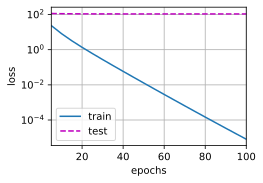

In [13]:
train(lambd=0)

w的L2范数是： 0.36104583740234375


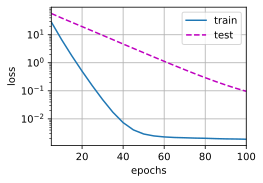

In [14]:
train(lambd=3)

In [ ]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
    for X, y in train_iter: # 遍历训练数据迭代器
        trainer.zero_grad() # 1. 梯度清零
        l = loss(net(X), y) # 2. 前向传播计算损失
        l.mean().backward() # 3. 反向传播计算梯度
        trainer.step()      # 4. 更新参数
        if (epoch + 1) % 5 == 0:# 每5个epoch记录并绘制一次损失
            animator.add(epoch + 1,
                         (evaluate_loss(net, train_iter, loss),
                          evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 13.018709182739258


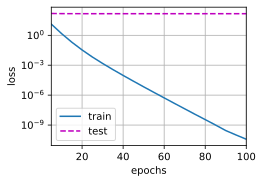

In [16]:
train_concise(0)

w的L2范数： 0.39344504475593567


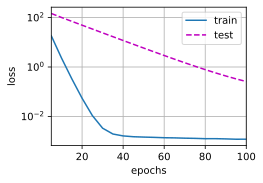

In [17]:
train_concise(3)